In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

In [2]:
DATA_PATH = Path("data/processed/videos_features.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (500, 26)

Columns:
['ID', 'Category', 'Channel', 'Title', 'URL', 'Duration', 'Views', 'Explanation_Type', 'Visuals', 'Examples', 'Analogies', 'Real_Life', 'Quality', 'Creator_Takeaways', 'duration_seconds', 'views_numeric', 'combined_text', 'has_analogy', 'has_example', 'has_visual', 'has_application', 'has_math', 'has_code', 'text_length', 'word_count', 'log_views']


In [3]:
print(df["combined_text"].head(3).to_string())

0    But what is a neural network? | Deep learning ...
1    Gradient descent, how neural networks learn | ...
2    A Gentle Introduction to Machine Learning Peda...


In [4]:
print("Missing combined_text:",
      df["combined_text"].isna().sum())

Missing combined_text: 0


In [5]:
%pip install sentence-transformers

Note: you may need to restart the kernel to use updated packages.


In [5]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

print("Embedding model loaded successfully!")

C:\Users\nagad\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3455.86it/s]


Embedding model loaded successfully!


In [6]:
texts = df["combined_text"].tolist()

embeddings = embedding_model.encode(
    texts,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("Embedding shape:", embeddings.shape)

Batches: 100%|██████████| 16/16 [00:01<00:00, 10.44it/s]

Embedding shape: (500, 384)


In [7]:
print("VID:", df["ID"].iloc[0])

print("\nFirst 20 embedding values:")
print(embeddings[0][:20])

VID: VID-001

First 20 embedding values:
[-0.07106042 -0.11540503  0.03630732 -0.0293228  -0.05697109  0.03582804
 -0.01882949 -0.01698158  0.00122407 -0.03824774 -0.04930689  0.01696666
 -0.00489505 -0.00814338 -0.13586862 -0.02465679 -0.00115916  0.07871739
 -0.07806868 -0.01433897]


In [8]:
EMBEDDING_PATH = Path(
    "data/processed/video_embeddings.npy"
)

np.save(EMBEDDING_PATH, embeddings)

print(f"Saved embeddings to: {EMBEDDING_PATH}")

Saved embeddings to: data\processed\video_embeddings.npy


In [9]:
loaded_embeddings = np.load(
    "data/processed/video_embeddings.npy"
)

print("Loaded shape:", loaded_embeddings.shape)

Loaded shape: (500, 384)


In [10]:
from sklearn.metrics.pairwise import cosine_similarity

In [11]:
similarity_matrix = cosine_similarity(embeddings)

print("Similarity matrix shape:",
      similarity_matrix.shape)

Similarity matrix shape: (500, 500)


In [12]:
video_index = 0

similarities = similarity_matrix[video_index]

similar_indices = np.argsort(
    similarities
)[::-1]

In [13]:
results = df.iloc[similar_indices[:6]][
    ["ID", "Title", "Category"]
].copy()

results["similarity"] = similarities[similar_indices[:6]]

results

,ID,Title,Category,similarity
0,VID-001,But what is a neural network? | Deep learning ...,Machine Learning (ML),1.000000
451,VID-452,Simple Neural Network in 3 Minutes,Machine Learning (ML),0.709700
20,VID-021,Neural Network Simply Explained | Deep Learnin...,Machine Learning (ML),0.689770
261,VID-262,"Backpropagation, intuitively | Deep Learning C...",Machine Learning (ML),0.640926
13,VID-014,Neural Networks Explained in 5 minutes,Machine Learning (ML),0.637762
21,VID-022,What are Convolutional Neural Networks (CNNs)?,Machine Learning (ML),0.609800


In [14]:
similar_indices = np.argsort(
    similarities
)[::-1]

similar_indices = [
    i for i in similar_indices
    if i != video_index
]

results = df.iloc[similar_indices[:5]][
    ["ID", "Title", "Category"]
].copy()

results["similarity"] = similarities[similar_indices[:5]]

results

,ID,Title,Category,similarity
451,VID-452,Simple Neural Network in 3 Minutes,Machine Learning (ML),0.709700
20,VID-021,Neural Network Simply Explained | Deep Learnin...,Machine Learning (ML),0.689770
261,VID-262,"Backpropagation, intuitively | Deep Learning C...",Machine Learning (ML),0.640926
13,VID-014,Neural Networks Explained in 5 minutes,Machine Learning (ML),0.637762
21,VID-022,What are Convolutional Neural Networks (CNNs)?,Machine Learning (ML),0.609800


In [15]:
query = "Explain neural networks to a beginner"

query_embedding = embedding_model.encode(
    [query],
    convert_to_numpy=True
)

In [16]:
query_similarity = cosine_similarity(
    query_embedding,
    embeddings
)[0]

In [17]:
ranked_indices = np.argsort(
    query_similarity
)[::-1]

In [18]:
query_results = df.iloc[
    ranked_indices[:10]
][
    ["ID", "Title", "Category", "Channel"]
].copy()

query_results["similarity"] = query_similarity[
    ranked_indices[:10]
]

query_results

,ID,Title,Category,Channel,similarity
0,VID-001,But what is a neural network? | Deep learning ...,Machine Learning (ML),3Blue1Brown,0.678711
20,VID-021,Neural Network Simply Explained | Deep Learnin...,Machine Learning (ML),codebasics,0.604823
451,VID-452,Simple Neural Network in 3 Minutes,Machine Learning (ML),3-Minute Data Science,0.598164
261,VID-262,"Backpropagation, intuitively | Deep Learning C...",Machine Learning (ML),3Blue1Brown,0.573666
238,VID-239,The spelled-out intro to neural networks and b...,LLM Architecture & Open Source Implementations,Andrej Karpathy,0.571496
13,VID-014,Neural Networks Explained in 5 minutes,Machine Learning (ML),IBM Technology,0.529707
1,VID-002,"Gradient descent, how neural networks learn | ...",Machine Learning (ML),3Blue1Brown,0.523092
19,VID-020,Neural Networks and Deep Learning: Crash Cours...,Machine Learning (ML),CrashCourse,0.523005
153,VID-154,Deep Q-Networks Explained!,Reinforcement Learning & Game Theory,CodeEmporium,0.521003
164,VID-165,Residual Networks (ResNet) [Physics Informed M...,Advanced Neural Architectures,Steve Brunton,0.518580


In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

embeddings_2d = pca.fit_transform(embeddings)

print(embeddings_2d.shape)

(500, 2)


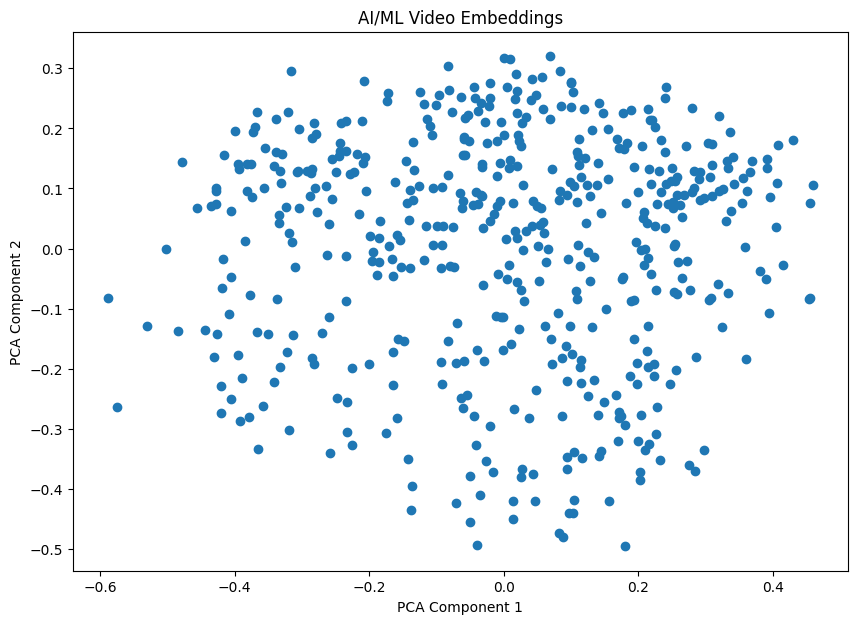

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1]
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("AI/ML Video Embeddings")

plt.show()

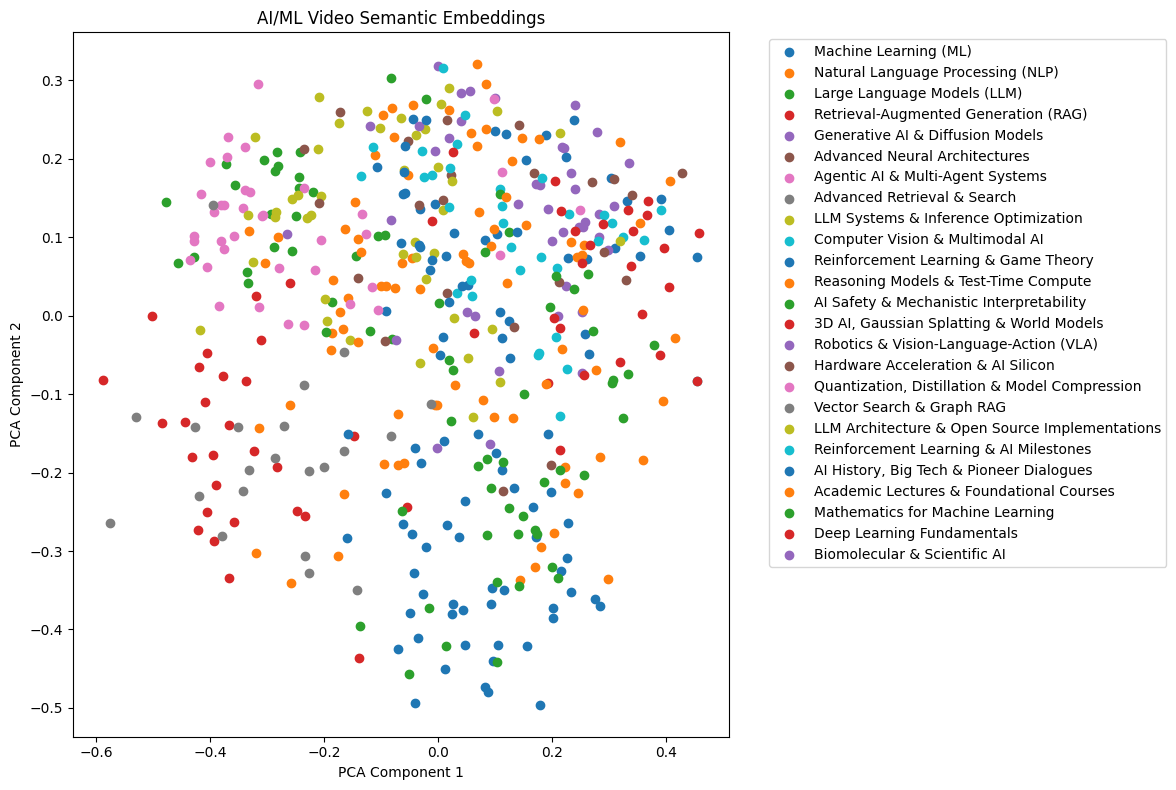

In [21]:
categories = df["Category"].unique()

plt.figure(figsize=(12, 8))

for category in categories:

    mask = df["Category"] == category

    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        label=category
    )

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("AI/ML Video Semantic Embeddings")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [22]:
print("Number of videos:", len(df))
print("Embedding dimensions:", embeddings.shape[1])
print("Embedding matrix:", embeddings.shape)
print("Saved:", EMBEDDING_PATH)

Number of videos: 500
Embedding dimensions: 384
Embedding matrix: (500, 384)
Saved: data\processed\video_embeddings.npy
